<a href="https://colab.research.google.com/github/Angappan95/langchain-practice/blob/main/14_multi_agent_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain langchain-core langchain-google-genai langchain-mcp-adapters tavily-python langsmith -q

In [2]:
from google.colab import userdata

GOOGLE_API_KEY = userdata.get("GOOGLE_API_KEY")
TAVILY_API_KEY = userdata.get("TAVILY_API_KEY")
LANGSMITH_API_KEY = userdata.get("LANGSMITH_API_KEY")

In [3]:
import os

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = "practice"

In [4]:
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime
from langgraph.checkpoint.memory import InMemorySaver
from langchain_google_genai.chat_models import ChatGoogleGenerativeAI
from tavily import TavilyClient
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langgraph.types import Command
from dataclasses import dataclass
from pprint import pprint

In [5]:
from langchain.agents import AgentState
from typing import List, Annotated
from langchain_core.messages import BaseMessage
import operator

@dataclass
class CustomState(AgentState):
    messages: Annotated[List[BaseMessage], operator.add]
    user_name: str
    origin: str
    destination: str
    venue: str

In [6]:
model = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    api_key=GOOGLE_API_KEY
)
model

ChatGoogleGenerativeAI(profile={}, google_api_key=SecretStr('**********'), model='gemini-3.1-flash-lite', temperature=1.0, client=<google.genai.client.Client object at 0x795d755b2ba0>, default_metadata=(), model_kwargs={})

[StructuredTool(name='search-flight', description='\n# Search for a flight\n\n## Description\n\nUses the Kiwi API to search for available flights between two locations on a specific date.\n\n## How it works\n\nThe tool will:\n1. Search for matching locations to resolve airport codes\n2. Find available flights for the specified route and date range\n\n## Method\n\nCall this tool whenever a user wants to search for flights, regardless of whether they provided exact airport codes or just city names.\n\nYou should display the returned results in a markdown table format: Group the results by price (those who are the cheapest), duration (those who are the shortest, i.e. have the smallest \'totalDurationInSeconds\') and the rest (those that could still be interesting).\n\nAlways display for each flight in order:\n  - In the 1st column: The departure and arrival airports, including layovers (e.g. "Paris CDG → Barcelona BCN → Lisbon LIS")\n  - In the 2nd column: The departure and arrival dates 

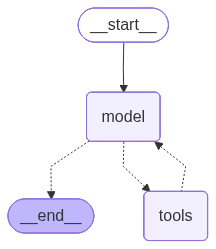

In [7]:
# tool for searching flight
from langchain_mcp_adapters.client import MultiServerMCPClient
from pprint import pprint

flight_search_mcp = MultiServerMCPClient({
    "travel_search": {
        "transport": "streamable_http",
        "url": "https://mcp.kiwi.com"
    }
})

tools = await flight_search_mcp.get_tools()
pprint(tools)

# create travel sub agent
system_prompt = '''
You are a Travel sub agent who help in
'''
flight_search_agent = create_agent(
    model=model,
    context_schema=AgentState,
    tools=tools,
    system_prompt=system_prompt
)

flight_search_agent

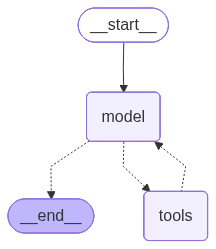

In [8]:
# tool for venue search
venue_search_client = MultiServerMCPClient({
    "venue-search-mcp": {
        "transport": "streamable-http",
        "url": "https://mcp.peek.com"
    }
})

venue_tools = await venue_search_client.get_tools()

# create venue sub agent
venue_search_agent = create_agent(
    model=model,
    tools=venue_tools,
    context_schema=AgentState
)
venue_search_agent

In [9]:
# tool for searching flight
@tool
async def search_flight(origin: str, destination: str, departure_date: str, runtime: ToolRuntime):
    '''Search flight between two places'''
    # The date format required by flight_search_agent.ainvoke is dd/mm/yyyy
    # Assuming the extracted departure_date is in a parseable format, we'll pass it directly.
    # More robust date parsing could be added here if needed.
    response_obj = await flight_search_agent.ainvoke({
        "messages": HumanMessage(f"Find flights between origin {origin} and destination {destination} for {departure_date}")
        })
    # Assuming response_obj is an AIMessage or similar with a .content attribute
    return str(response_obj['messages'][-1].content[-1]['text'])


# tool for searching venue
@tool
async def search_venue(destination: str, query: str, runtime: ToolRuntime):
    '''Search venues for provided place'''
    response_obj = await venue_search_agent.ainvoke({
        "messages": HumanMessage(f"Find the best {query} details in {destination}")
        })
    # Assuming response_obj is an AIMessage or similar with a .content attribute
    return str(response_obj['messages'][-1].content[-1]['text'])


# tool for updating states
@tool
def update_state(user_name:str, origin:str, destination: str, venue:str, runtime: ToolRuntime):
    '''Update state'''
    return Command(update={
        "user_name": user_name,
        "origin": origin,
        "destination": destination,
        "venue":venue,
        "messages": [ToolMessage(content="State is Successfully updated", tool_call_id=runtime.tool_call_id)]
    })

In [10]:
system_prompt = '''You are a Travel coordinator. Your task is to manage trip planning by following a strict sequence.
1. **Identify and Extract Key Information:** Your absolute first action is to carefully identify and extract the 'user_name', 'origin', 'destination', 'venue' preferences, and 'departure_date' from the user's current message.
2. **Mandatory State Update:** IMMEDIATELY after extracting this information, you MUST call the 'update_state' tool. This is the ONLY tool you are allowed to call at this initial stage. You MUST provide all extracted 'user_name', 'origin', 'destination', and 'venue' parameters to the 'update_state' tool. This step is crucial for setting up the trip context and MUST be completed successfully before any other action.
3. **Deferred Actions:** You MUST NOT call 'search_flight' or 'search_venue' before the 'update_state' tool has been successfully executed and the conversation state is confirmed to contain 'user_name', 'origin', 'destination', and 'venue'.
4. **Subsequent Task Delegation:** ONLY AFTER the state has been successfully updated by 'update_state' should you proceed to delegate further tasks.
    - If the user wants flight information, use the 'search_flight' tool. You MUST call it with the extracted 'origin', 'destination', and 'departure_date'.
    - If the user wants venue information, use the 'search_venue' tool. You MUST call it with the extracted 'destination' and the 'venue' preference (pass 'venue' as the 'query' argument).
5. **Handle Missing Information:** If you cannot find all the necessary information (user_name, origin, destination, venue, departure_date) from the initial message, you MUST politely prompt the user to provide the missing details.
'''

coordinator_agent = create_agent(
    model=model,
    tools = [search_flight, search_venue, update_state],
    system_prompt=system_prompt,
    context_schema=CustomState
    )

In [11]:
# invoke coordinator agent and check if the states are populated correctly
from pprint import pprint
config = {'configurable': {'thread_id': '101'}}
response = await coordinator_agent.ainvoke({'messages': HumanMessage("Help Arjun to plan for holiday trip from Chennai to Andaman for Jun 10, 2026. Choose best adventure venues and suggest the plan to Arjun")}, config=config)

pprint(response)

{'messages': [HumanMessage(content='Help Arjun to plan for holiday trip from Chennai to Andaman for Jun 10, 2026. Choose best adventure venues and suggest the plan to Arjun', additional_kwargs={}, response_metadata={}, id='9e6985eb-e15a-45d9-8574-4497c96235a9'),
              AIMessage(content=[], additional_kwargs={'function_call': {'name': 'update_state', 'arguments': '{"user_name": "Arjun", "destination": "Andaman", "origin": "Chennai", "venue": "adventure venues"}'}, '__gemini_function_call_thought_signatures__': {'7e125c91-281c-4595-8cd4-25db4ad4c4b2': 'EjQKMgEMOdbHFurWVv4qezSjiNpM2/J1/H5bFdkDcWRxbga7yBXBLXsnmLgLE5BGqkwaF9ld'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e2b05-650b-7a22-bc16-be7c8debb6c6-0', tool_calls=[{'name': 'update_state', 'args': {'user_name': 'Arjun', 'destination': 'Andaman', 'origin': 'Chennai', 'venue': 'adventure venues'}, 'id': '7e125c91-281c

In [16]:
pprint(response['messages'])

[HumanMessage(content='Help Arjun to plan for holiday trip from Chennai to Andaman for Jun 10, 2026. Choose best adventure venues and suggest the plan to Arjun', additional_kwargs={}, response_metadata={}, id='9e6985eb-e15a-45d9-8574-4497c96235a9'),
 AIMessage(content=[], additional_kwargs={'function_call': {'name': 'update_state', 'arguments': '{"user_name": "Arjun", "destination": "Andaman", "origin": "Chennai", "venue": "adventure venues"}'}, '__gemini_function_call_thought_signatures__': {'7e125c91-281c-4595-8cd4-25db4ad4c4b2': 'EjQKMgEMOdbHFurWVv4qezSjiNpM2/J1/H5bFdkDcWRxbga7yBXBLXsnmLgLE5BGqkwaF9ld'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e2b05-650b-7a22-bc16-be7c8debb6c6-0', tool_calls=[{'name': 'update_state', 'args': {'user_name': 'Arjun', 'destination': 'Andaman', 'origin': 'Chennai', 'venue': 'adventure venues'}, 'id': '7e125c91-281c-4595-8cd4-25db4ad4c4b2', 

In [15]:
print(response['messages'][-1].content[-1]['text'])

Hello Arjun! I have successfully updated your trip information for your upcoming holiday to Andaman.

### Flight Options (Chennai to Port Blair on June 10, 2026)
I have found several flight options for your travel. The **direct flights** are the most convenient, taking only 2 hours and 15 minutes. 
*   **Best Price:** You can book a direct flight for **63 EUR**.
*   **Recommended:** The 07:40 AM departure (arriving at 09:55 AM) is a great option to start your holiday early. You can find the booking details [here](https://on.kiwi.com/mbmRzS).

### Adventure Recommendations in Andaman
Andaman is a fantastic choice for adventure. Here are some top-rated experiences you should consider for your itinerary:
1.  **Snorkeling & Marine Life:** Explore the Phi Phi Islands or the Surin Islands for world-class snorkeling and the chance to swim with reef sharks or witness bioluminescent plankton.
2.  **Rock Climbing:** If you are looking for a challenge, the limestone cliffs at Railay Beach in Krab